# Cellular Automata z Informatyki Systemów Złożonych

Zadania z pliku `LAB_2.docx` zostały przygotowane przez: _prof. dr hab. inż. Witold Dzwinel_.

Zadania wykonane przez: _Wojciech Kosztyła_.

## Imports

In [2]:
!pip install cellpylib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for cellpylib: filename=cellpylib-2.3.1-py3-none-any.whl size=37202 sha256=aaa5f12e8d1c7491cfafe1463da67eaa4d7ef72a058eaf9fd8698663fc25c511
  Stored in directory: /root/.cache/pip/wheels/13/16/78/edab40676fff7d27f78a3da537946152ecaa29d267e82b14b8
Successfully built cellpylib


In [54]:
import pandas

# Zadania


## Zadanie 1

Sprawdź czy potrafisz uruchomić wszystkie elementarne Automaty Komórkowe 
zgodnie z https://cellpylib.org/eca.html. 

### 1.a
Wybierz niebanalne automaty 30, 45, 106, 154, zwizualizuj je i policz dla nich miary 
złożoności zgodnie z Measures of Complexity, https://github.com/lantunes/cellpylib. 


In [15]:
import cellpylib as cpl
import matplotlib as plt
plt.rcParams['figure.figsize'] = [10, 8]

def plotNiebanalnyAutomat(ruleNumber:int):
  cellular_automaton = cpl.init_simple(200)
  cellular_automaton = cpl.evolve(cellular_automaton, 
                                  timesteps=100, 
                                  memoize=True,
                                  apply_rule=lambda n, 
                                    c, 
                                    t: cpl.nks_rule(n, ruleNumber)
                                  )
  
  avg_cell_entropy = cpl.average_cell_entropy(cellular_automaton)
  avg_mutual_information = cpl.average_mutual_information(cellular_automaton)

  cpl.plot(cellular_automaton, title=f'Rule {ruleNumber}, \navg_cell_entropy={avg_cell_entropy}, \navg_mutual_information={avg_mutual_information}')
  print('\n')

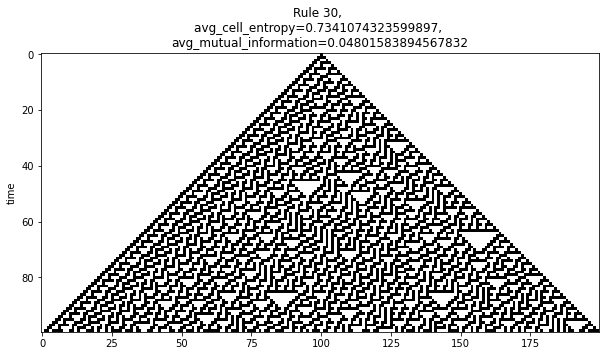

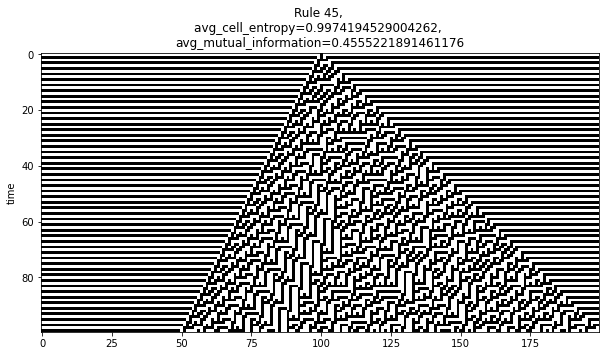

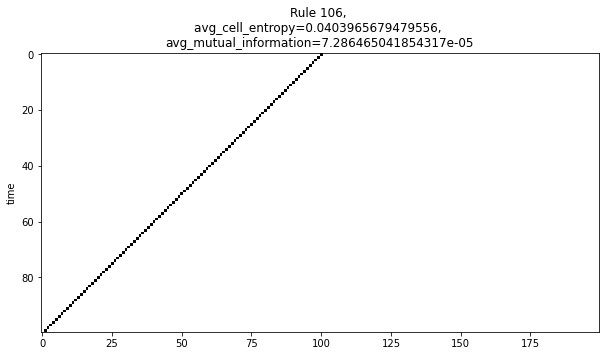

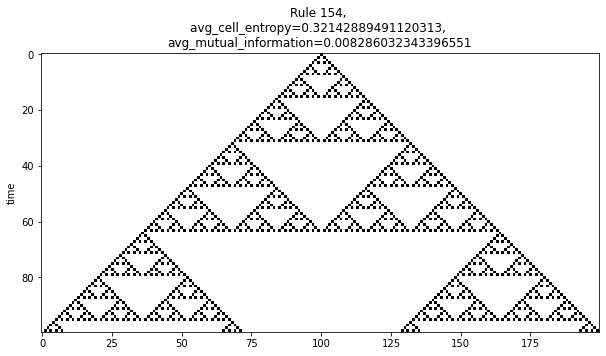

In [16]:
plotNiebanalnyAutomat(30)
plotNiebanalnyAutomat(45)
plotNiebanalnyAutomat(106)
plotNiebanalnyAutomat(154)

### 1.b
Sformułuj wnioski.

Ta biblioteka bardzo ulatwia prowadzenie badan nad automatami. Wszystkie przyklady wyszly zgodnie z oczekiwaniami. 
Liczenie miar zlozonosci rowniez bylo bardzo proste.

## Zadanie 2


### 2.a

Zdefiniuj Langton Edge of chaos zmieniając parametr lambda dla 1-D automatu 
komórkowego z k stanami i n sąsiadami. Pomoc: https://math.hws.edu/eck/js/edge-of-chaos/CA.html.

In [1]:
import cellpylib as cpl
import matplotlib as plt

def plotAutomatParametry(
    lambda_val:float=0.5, 
    number_of_states:int = 2, 
    neighbourhood_size:int = 3, 
    custom_figsize=[10, 16], 
    dont_plot:bool=False):

  plt.rcParams['figure.figsize'] = custom_figsize
  r = int((neighbourhood_size-1)/2)

  rule_table, actual_lambda, quiescent_state = cpl.random_rule_table(lambda_val=0.33, 
                                                                    k=number_of_states, 
                                                                    r=r,
                                                                    #strong_quiescence=True, 
                                                                    isotropic=True)

  cellular_automaton = cpl.init_random(200, k=number_of_states)

  # use the built-in table_rule to use the generated rule table
  cellular_automaton = cpl.evolve(cellular_automaton, 
                                  timesteps=300,
                                  apply_rule=lambda n, c, t: cpl.table_rule(n, rule_table), 
                                  r=r)

  avg_cell_entropy = cpl.average_cell_entropy(cellular_automaton)
  avg_mutual_information = cpl.average_mutual_information(cellular_automaton)

  if not dont_plot:
    cpl.plot(cellular_automaton, title=f'k={number_of_states}, r={r}, lambda={lambda_val}, \navg_cell_entropy={avg_cell_entropy}, \navg_mutual_information={avg_mutual_information}')
    print('\n')
  return {"avg_cell_entropy": avg_cell_entropy, "avg_mutual_information": avg_mutual_information}



ModuleNotFoundError: ignored

In [19]:
rozne_opcje = [
    # [number_of_states, neighbourhood_size, lambda_val]
    [2, 3, 0.1579],
    [2, 3, 0.4211],
    [2, 3, 0.8947],

    [7, 3, 0.1641],
    [7, 3, 0.3385],
    [7, 3, 0.7179],

    [2, 5, 0.2105],
    [2, 5, 0.6316],
    [2, 5, 0.8947],

    [7, 5, 0.3599],
    [7, 5, 0.4491],
    [7, 5, 0.6975],
]

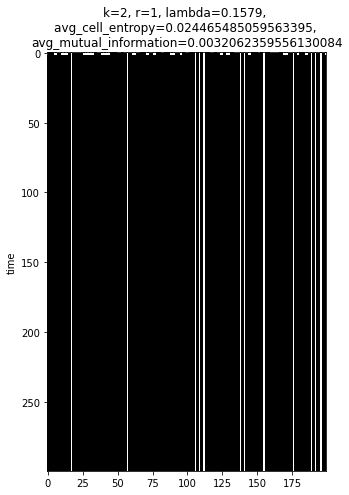

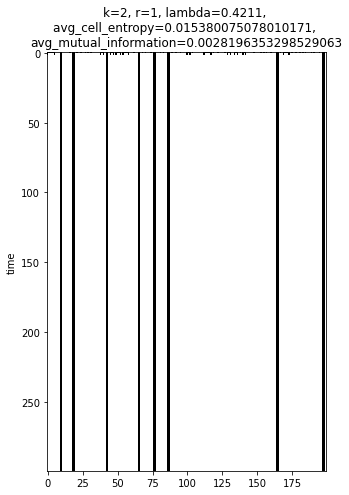

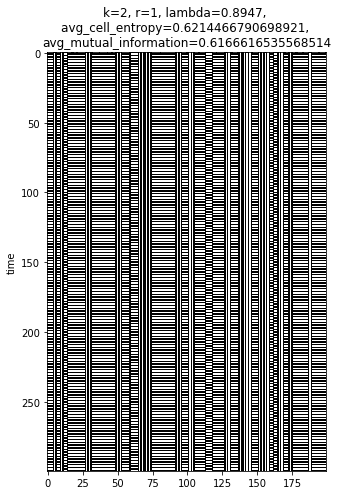

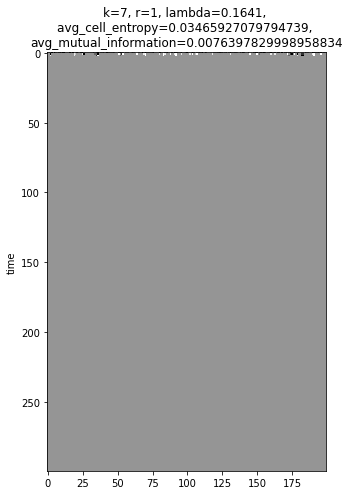

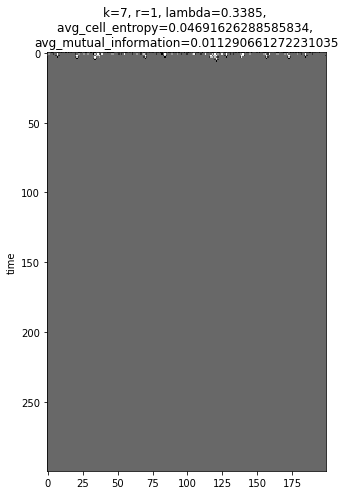

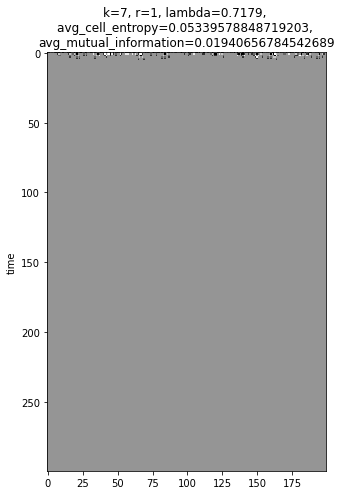

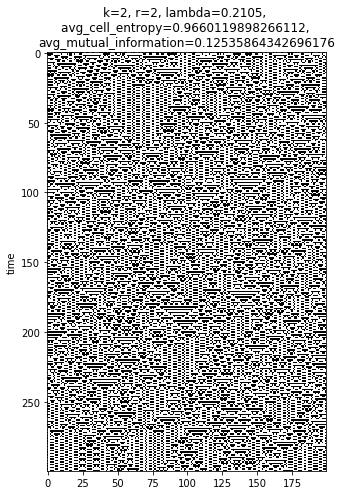

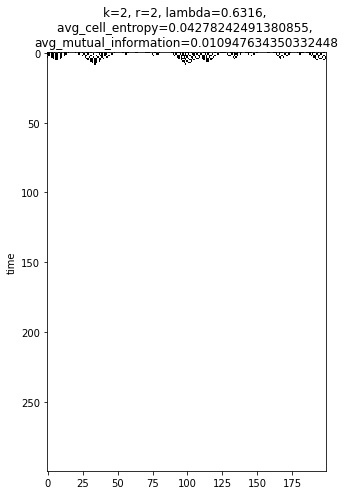

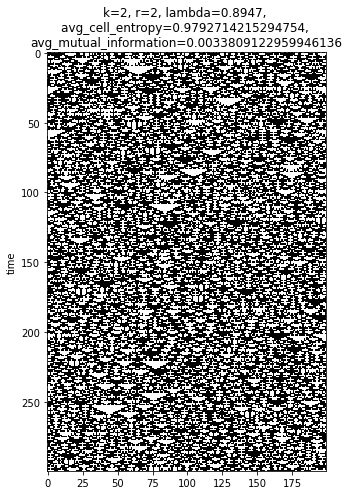

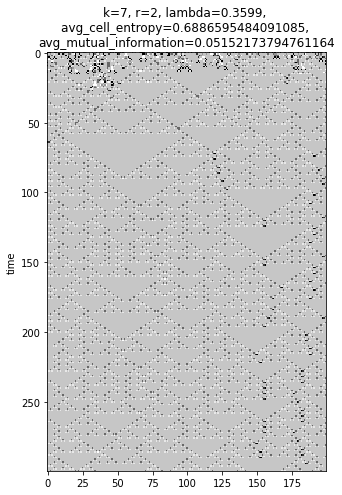

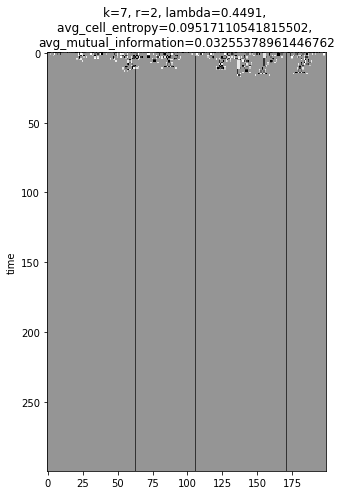

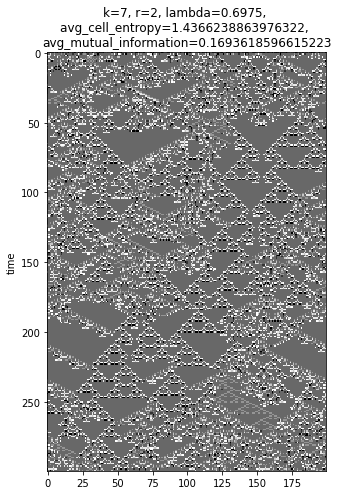

In [20]:
for parametry in rozne_opcje:
  plotAutomatParametry(lambda_val=parametry[2], number_of_states=parametry[0], neighbourhood_size=parametry[1], custom_figsize=[5,8])

### 2.b

Policz miary złożoności dla krytycznych lambda dla różnych k i n. Wyniki przedstaw w tabelach k-n. Pomóż sobie: https://github.com/lantunes/cellpylib.

In [55]:
krytyczne_opcje = [
    # [number_of_states, neighbourhood_size, lambda_val]
    [2, 3, 0.4211],

    [7, 3, 0.3385],

    [2, 5, 0.6316],

    [7, 5, 0.4491]
]

In [62]:
wyniki_avg_cell_entropy = []
wyniki_avg_mutual_information = []
nazwy_kolumn = []
nazwy_wierszy = []

for parametry in krytyczne_opcje:
  wynik = plotAutomatParametry(
      lambda_val=parametry[2], 
      number_of_states=parametry[0], 
      neighbourhood_size=parametry[1], 
      dont_plot=True)
  
  wyniki_avg_cell_entropy.append([
      parametry[0],
      parametry[1], 
      wynik["avg_cell_entropy"]
      ])
  wyniki_avg_mutual_information.append([
      parametry[0],
      parametry[1],
      wynik["avg_mutual_information"]
      ])

  if f"k={parametry[0]}" not in nazwy_kolumn:
    nazwy_kolumn.append(f"k={parametry[0]}")
  if f"r={parametry[1]}" not in nazwy_wierszy:
    nazwy_wierszy.append(f"r={parametry[1]}")


In [63]:
df = pandas.DataFrame([[0.0,0.0],[0.0,0.0]])
df.columns = nazwy_kolumn
df.index = nazwy_wierszy

for wynik in wyniki_avg_cell_entropy:
  kolumna = f"k={wynik[0]}"
  wiersz = f"r={wynik[1]}"
  df[kolumna][wiersz] = wynik[2]

print("Wyniki Average Cell Entropy")
df

Wyniki Average Cell Entropy


,k=2,k=7
r=3,0.025474,0.051366
r=5,0.986452,0.059304


In [64]:
df = pandas.DataFrame([[0.0,0.0],[0.0,0.0]])
df.columns = nazwy_kolumn
df.index = nazwy_wierszy

for wynik in wyniki_avg_mutual_information:
  kolumna = f"k={wynik[0]}"
  wiersz = f"r={wynik[1]}"
  df[kolumna][wiersz] = wynik[2]

print("Wyniki Average Mutual Information")
df

Wyniki Average Mutual Information


,k=2,k=7
r=3,0.006123,0.012436
r=5,0.041287,0.014849


### 2.c

Sformułuj wnioski.

Korzystając z załączonej strony z symulacją zauważyłem, że tworząc nowy zestaw zasad przy tych samych parametrach bardzo znacząco wpływa na osiągany wynik. 

Z `Average cell entropy` zauważamy zgodnie z przewidywaniem, że zwiększenie rozmiaru sąsiedztwa wpływa na wzrost entropii.
To samo tyczy się `Avera mutual information`.

## Zadanie 3


### 3.a

Zrób to samo dla automatu ciągłego https://cellpylib.org/continuous.html. z tym, że zastosuj regułę logistyczną: $x_i= lambda * x_iś* (1-x_iś)$, gdzie $x_i$ stan automatu na pozycji $i$, a $x_iś$ to średnia ze stanów sąsiednich.

In [57]:
import cellpylib as cpl
import matplotlib as plt
import math
import numpy as np

def plotAutomatCiagly(
    lambda_val:float=0.5, 
    number_of_states:int = 2, 
    neighbourhood_size:int = 3, 
    custom_figsize=[10, 16], 
    dont_plot:bool=False,
    timesteps:int=300):
  
  def apply_nasza_regula_logistyczna(n, c, t, lambda_val):
    x_is = sum(n) / len(n)
    result = lambda_val * x_is * (1 - x_is)
    frac, whole = math.modf(result)
    return frac

  plt.rcParams['figure.figsize'] = custom_figsize
  r = int((neighbourhood_size-1)/2)

  cellular_automaton = cpl.init_random(200, dtype=np.float64)
  cellular_automaton = cpl.evolve(cellular_automaton, 
                                  timesteps=timesteps,
                                  apply_rule=lambda n, c, t: apply_nasza_regula_logistyczna(n, c, t, lambda_val), 
                                  r=r)

  avg_cell_entropy = cpl.average_cell_entropy(cellular_automaton)
  avg_mutual_information = cpl.average_mutual_information(cellular_automaton)

  if not dont_plot:
    cpl.plot(cellular_automaton, title=f'r={r}, lambda={lambda_val}, \navg_cell_entropy={avg_cell_entropy}, \navg_mutual_information={avg_mutual_information}')
    print('\n')
  return {"avg_cell_entropy": avg_cell_entropy, "avg_mutual_information": avg_mutual_information, "avg_cala_tablica": cellular_automaton.mean()}



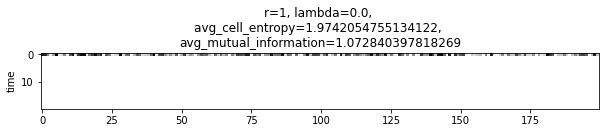

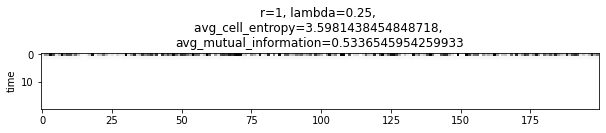

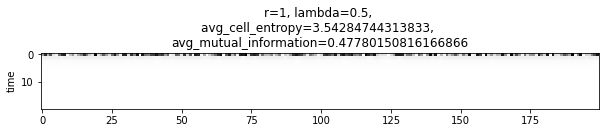

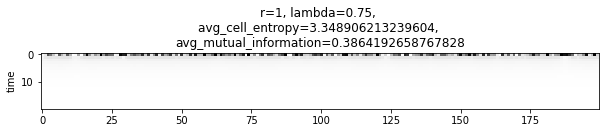

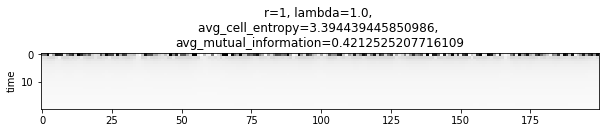

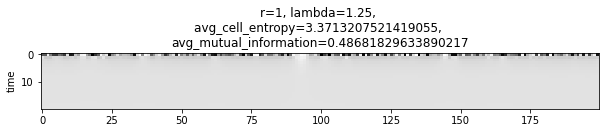

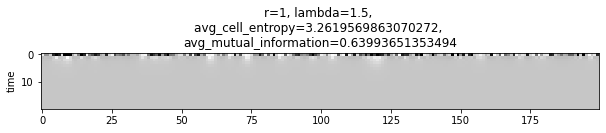

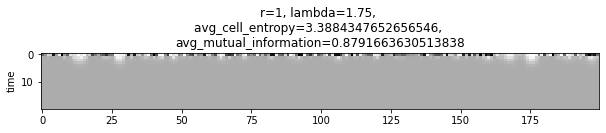

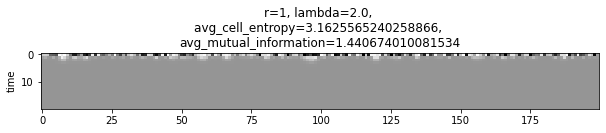

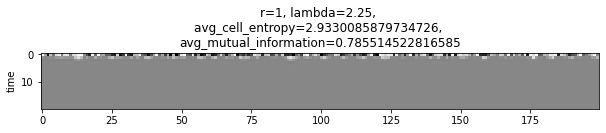

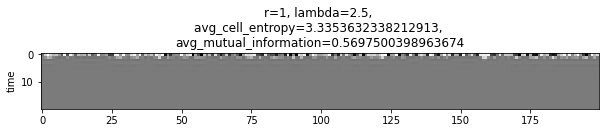

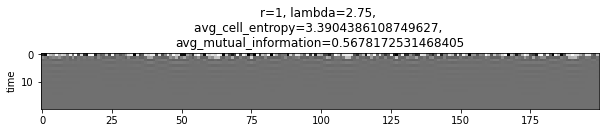

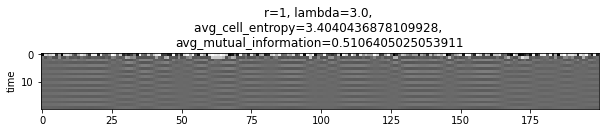

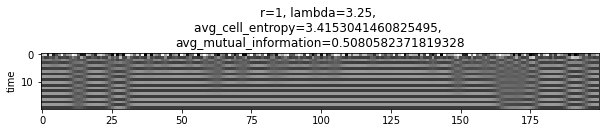

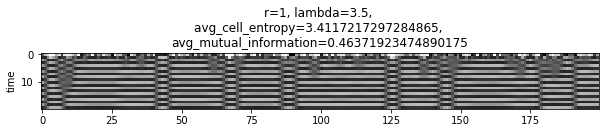

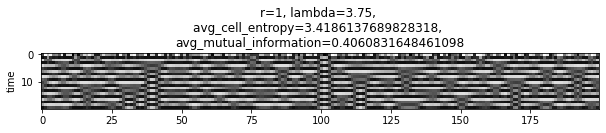

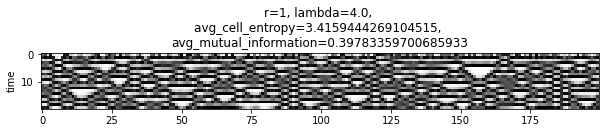

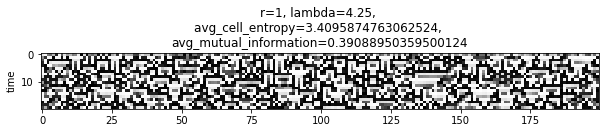

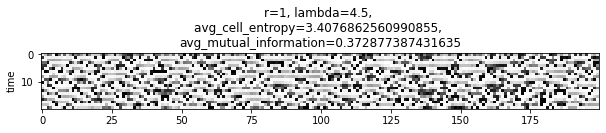

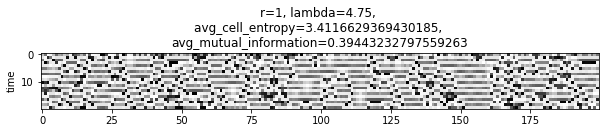

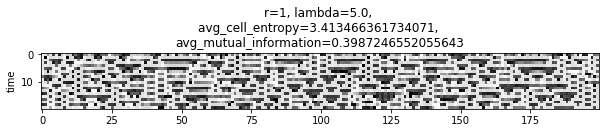

In [33]:
for i in range(21):
  plotAutomatCiagly(lambda_val=(2.5 * i / 10), timesteps=20)

Widzimy, że w przypadku sąsiedztwa o promieniu 1, wyniki dla $lambda<=2.75$ wyniki wygaszają się w pierwszych kilku iteracjach. "Ciekawe" otrzymujemy około $lambda>=4.25$.

Edge of Chaos wydaje się padać na okolice $lambda=3$, co można było przewidzieć.

W naszej funkcji $x_i= lambda * x_iś* (1-x_iś)$, z racji losowych wartości początkowych z zakresu $[0,1]$ wartość $x_iś$ powinna być bardzo zbliżona do $0.5$.

W takim wypadku wynik $x_i=lambda*0.5*0.5 = lambda/4$ dla lambd, które wykorzystywaliśmy wcześniej ($[0,1]$) szybko "wycisza" wszystkie wartości. 

Przy $lambda=3$ średnia wartość zwracana przez naszą funkcję logistyczną wynosi 0.5. 

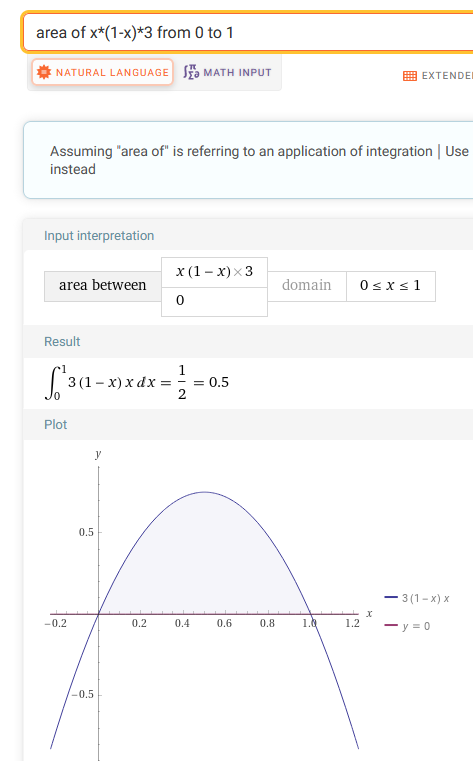

### 3.b

Zrobić to dla różnej wielkości sąsiedztwa $n$. Wartości $x_i$ są z przedziału $[0,1]$ i są liczbami rzeczywistymi.

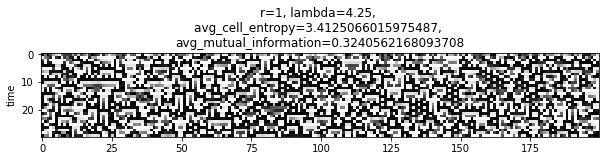

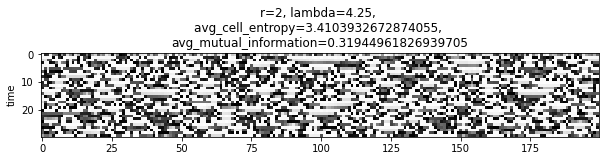

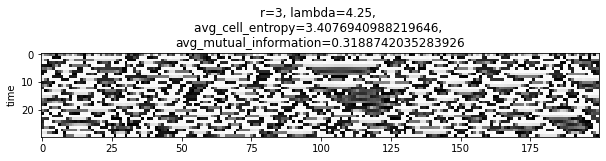

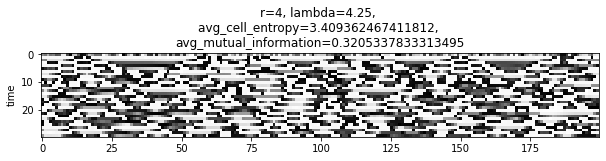

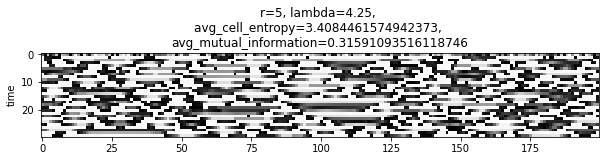

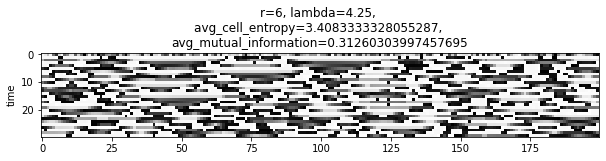

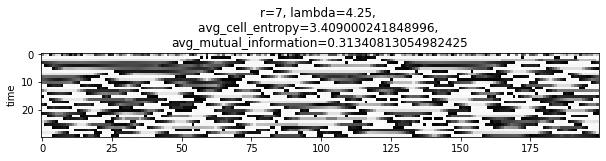

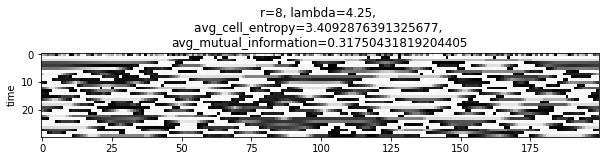

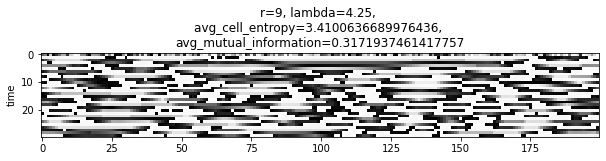

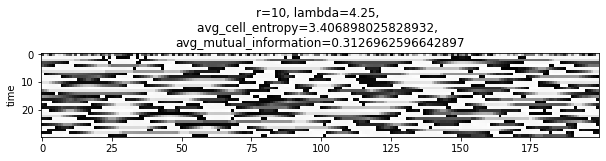

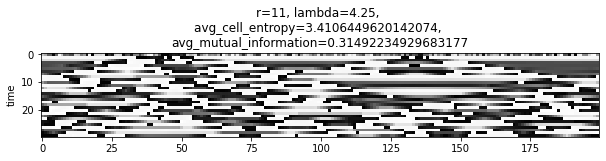

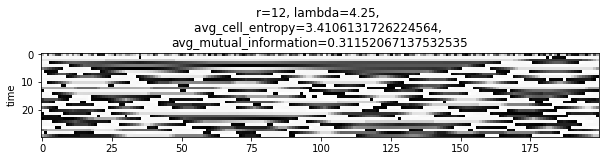

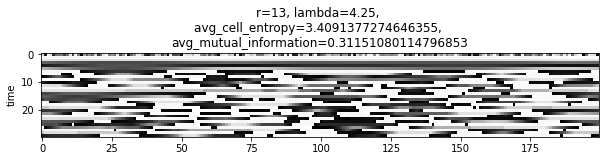

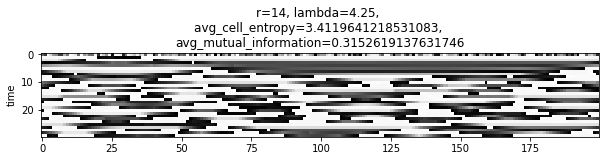

In [42]:
for r in range(1, 15):
  plotAutomatCiagly(lambda_val=4.25, neighbourhood_size=(2*r+1), timesteps=30)

Widzimy tutaj, że im większy jest zasięg sąsiedztwa, tym bardziej "kreskowe" (poziomo) robią się nasze automaty. 
Jest to spowodowane tym, iż zmiana jednej z wartości początkowej wpływa z coraz to mniejszym iloczynem na wynik następnej iteracji.

Przy $n=1$ wpływa w stopniu $~1/3$, natomiast przy $n=14$ wpływa w stopniu $~1/29$.

### 3.c

Narysuj krzywą $x_ś = f(lambda)$ gdzie $x_ś$ jest średnią po całej tablicy.

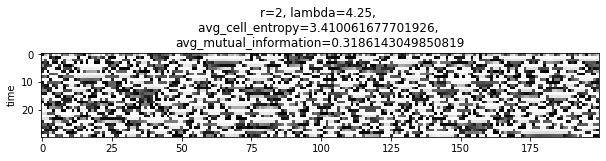

0.43192411554729004

In [61]:
plotAutomatCiagly(lambda_val=4.25, neighbourhood_size=5, timesteps=30)["avg_cala_tablica"]

In [79]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,5]

lambda_values = []
x_avg_values = []
cell_entropy_avg_values = []
mutual_information_avg_values = []
samples = 100

for lambda_val in np.linspace(0.1, 5.0, num=samples, endpoint=False):
  lambda_values.append(lambda_val)
  wyniki = plotAutomatCiagly(lambda_val=lambda_val, neighbourhood_size=5, timesteps=50, dont_plot=True)
  
  x_avg_values.append(wyniki["avg_cala_tablica"])
  mutual_information_avg_values.append(wyniki["avg_mutual_information"])
  cell_entropy_avg_values.append(wyniki["avg_cell_entropy"])

  print(".", end = '')


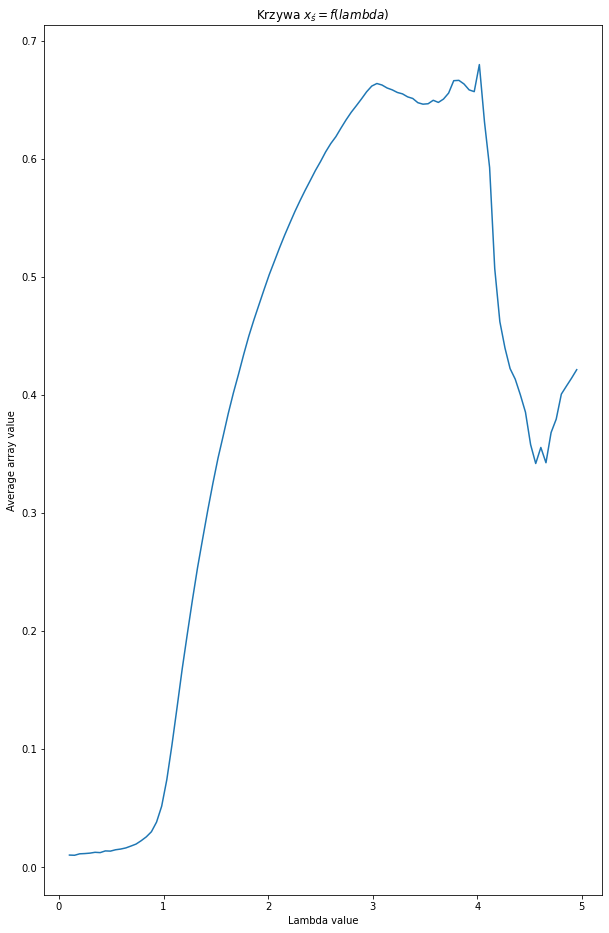

In [80]:
plt.plot(lambda_values, x_avg_values)
plt.title("Krzywa $x_ś = f (lambda)$")
plt.xlabel("Lambda value")
plt.ylabel("Average array value")
plt.show()

Jak wcześniej wspominałem, widać tutaj zmianę wartości w okolicach $lambda=3$. Potem zachowanie robi się bardziej chaotyczne.

### 3.d

Policz miary złożoności tam, gdzie to ci się wydaje potrzebne.

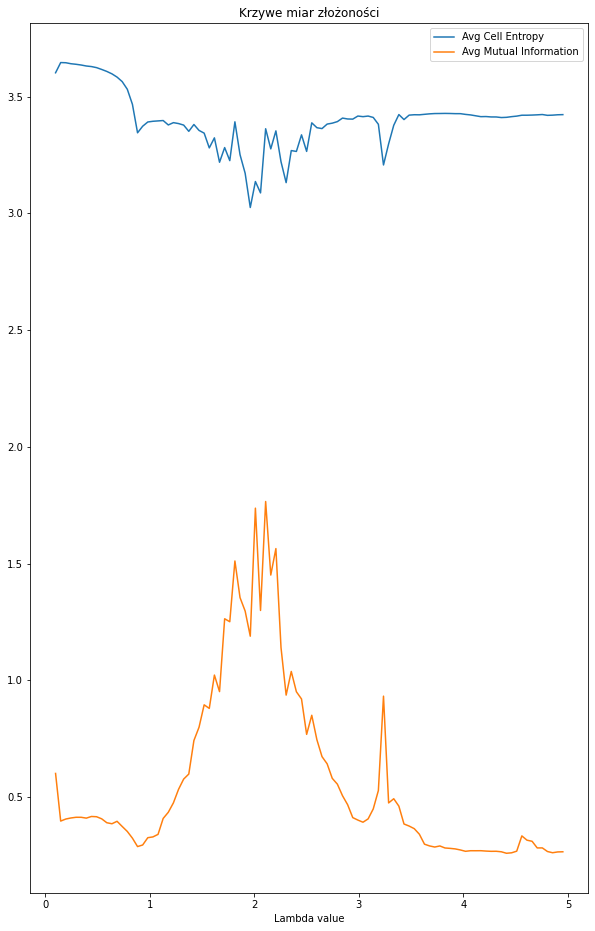

In [81]:
plt.plot(lambda_values, cell_entropy_avg_values, label='Avg Cell Entropy')
plt.plot(lambda_values, mutual_information_avg_values, label='Avg Mutual Information')
plt.xlabel("Lambda value")
plt.title("Krzywe miar złożoności")
plt.legend()
plt.show()

Patrząc na te wykresy widzimy, że nasz Edge of Chaos przypada jednak bardziej w okolice $lambda=2$ niż moje wcześniejsze zgadnięcie "na oko" (2.7).

### 3.e

Sformułuj wnioski.

Wnioski formułowałem odpowiednio pod każdym podpunktem.